<font size = 10>Quadratic</font>

# Local run setup: Windows vs Mac

Set `PLATFORM` below to `"Windows"` or `"Mac"`.

This notebook runs locally on both systems. It uses **NumPy** and **Matplotlib** only, so it does **not** need GPU acceleration. The platform flag is included mainly for consistency with the other local notebooks.

- `PLATFORM` lets you mark whether you are running on **Mac** or **Windows**
- No CUDA / MPS setup is required in this notebook
- Once `numpy` and `matplotlib` are installed, the notebook should run the same on both systems


In [1]:
# ===== Local platform selector =====
# Set this to: "Windows" or "Mac"
PLATFORM = "Mac"

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

platform_normalized = PLATFORM.strip().lower()
if platform_normalized not in {"mac", "windows"}:
    raise ValueError('PLATFORM must be "Windows" or "Mac".')

print(f"PLATFORM = {PLATFORM}")
print("This notebook uses NumPy and Matplotlib only, so no GPU setup is needed.")


PLATFORM = Mac
This notebook uses NumPy and Matplotlib only, so no GPU setup is needed.


# Definitions 
## Let's assume that we need to minimize the following *cost function*:

$\huge C(x) = a \cdot x^2 + b \cdot x + c$

## Cost Function derivative
$\huge \frac {dC(x)}{dx} = 2 \cdot a \cdot x + b$


In [2]:
def cost_function(a, b, c, x): 
    return a*x**2 + b*x + c

def d_cost_function(a,b,c, x):
    return 2*a*x+b

# Objective
Find $x$ that minimizes $C(x)$ for a set of parameters $a, b, c$

In [3]:
a, b, c = 2, -5, 0

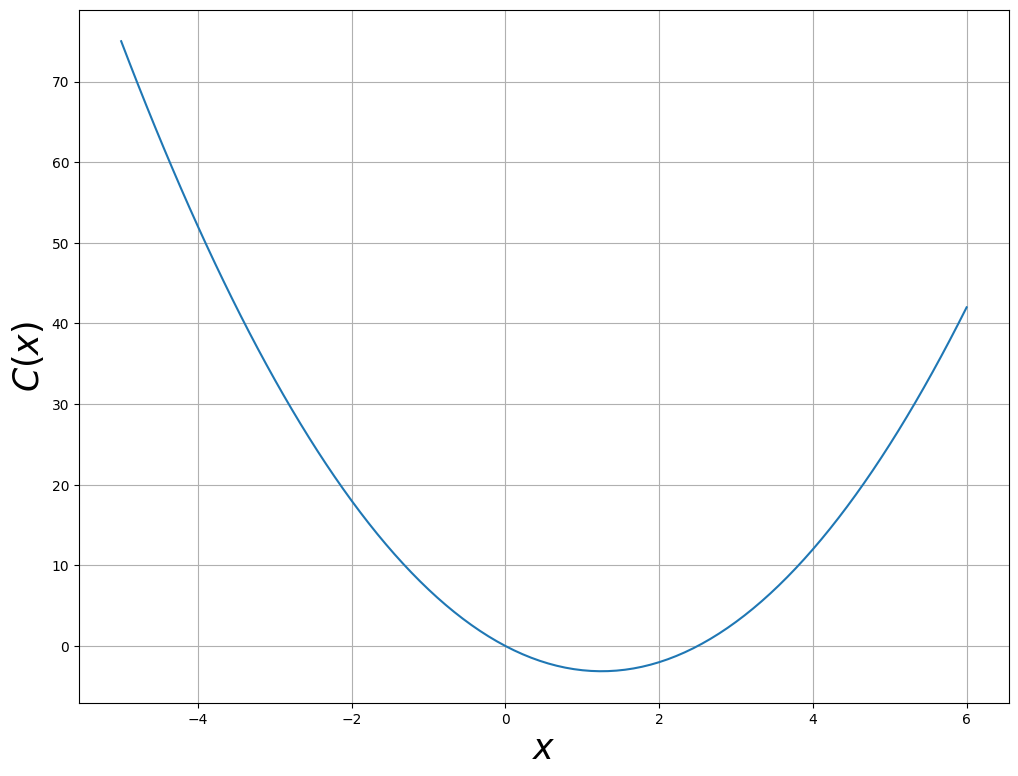

In [4]:
x = np.linspace(-5,6, 100)
fig, ax = plt.subplots(figsize = (12,9))
plt.plot(x, cost_function(a,b,c,x))
plt.grid(True)
ax.set_xlabel('$x$', fontsize=25); ax.set_ylabel('$C(x)$', fontsize=25);

$ \large \frac {dC(x)}{dx}$ suggests that 
- $\large x's$ for which $ \large \frac {dC(x)}{dx}<0$ are too small. Increase $x$
- $ \large x's$ for which $ \large \frac {dC(x)}{dx}>0$ are too large. Decrease $x$

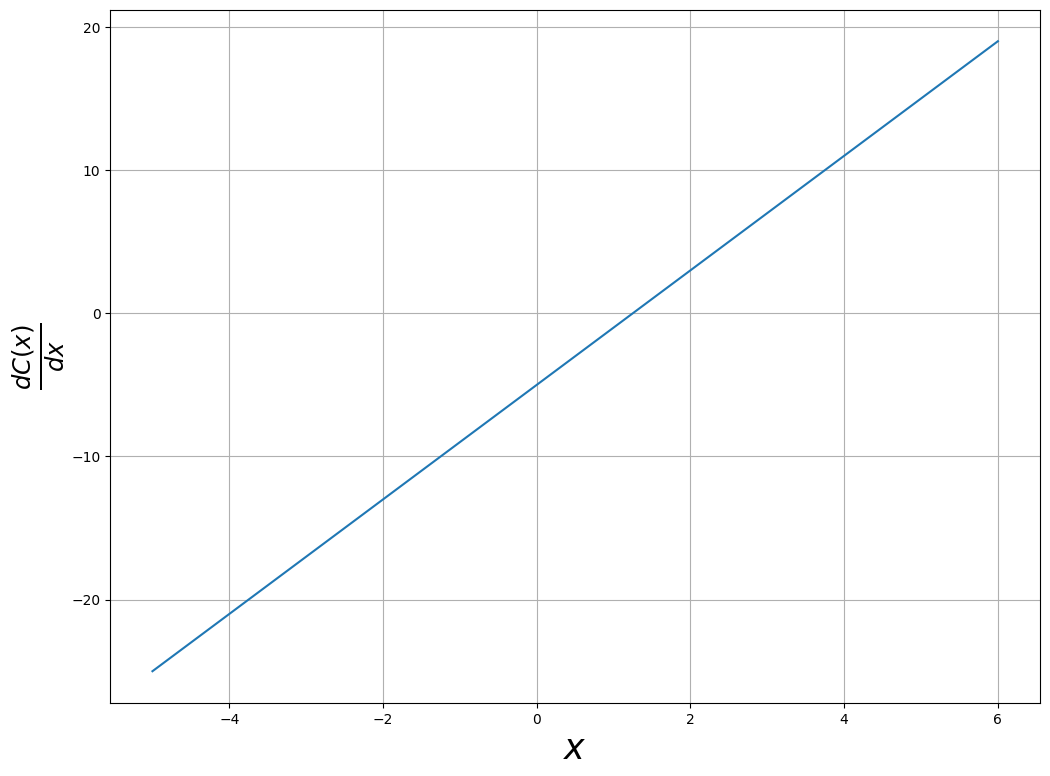

In [5]:
x = np.linspace(-5,6, 100)
fig, ax = plt.subplots(figsize = (12,9))
plt.plot(x, d_cost_function(a,b,c,x))
plt.grid(True)
ax.set_xlabel('$x$', fontsize=25); ax.set_ylabel(r'$ \frac {dC(x)}{dx}$', fontsize=25);

In [6]:
def compute_gradient_descent(x0, lr, steps):
    xs = np.zeros( (steps+1,))
    xs[0] = x0
    for i in range(1,steps+1):        
        x0 = x0- lr * d_cost_function(a,b,c, x0)
        xs[i] = x0
    return np.array(xs)

In [7]:
def plot_gradient_descent(xs, lr):
    x = np.linspace(-5,6, 100)
    fig, ax = plt.subplots(figsize = (12,9))
    plt.plot(x, cost_function(a,b,c,x), linewidth=3)
    ax.set_xlabel('$x$', fontsize=25); ax.set_ylabel('$C(x)$', fontsize=25)
    # plot tested values
    ax.scatter(xs, cost_function(a,b,c, xs),s=70, c='red')
    # plot arrows
    for i in range(1, len(xs)):
        x1 = xs[i-1]
        y1 = cost_function(a,b,c,x1)

        x2 = xs[i]
        y2 = cost_function(a,b,c,x2)

        ax.arrow( x1, y1, x2-x1, y2-y1, width=0.05, length_includes_head=True,color='green',
                  head_width=0.25, head_length=0.5, capstyle='projecting')
    for i in range(len(xs)):
        ax.annotate(str(i+1), (xs[i], cost_function(a,b,c,xs[i])), fontsize=25)
        
    ax.set_title(f"Gradient Descent with learning rate {lr}", fontsize=25)

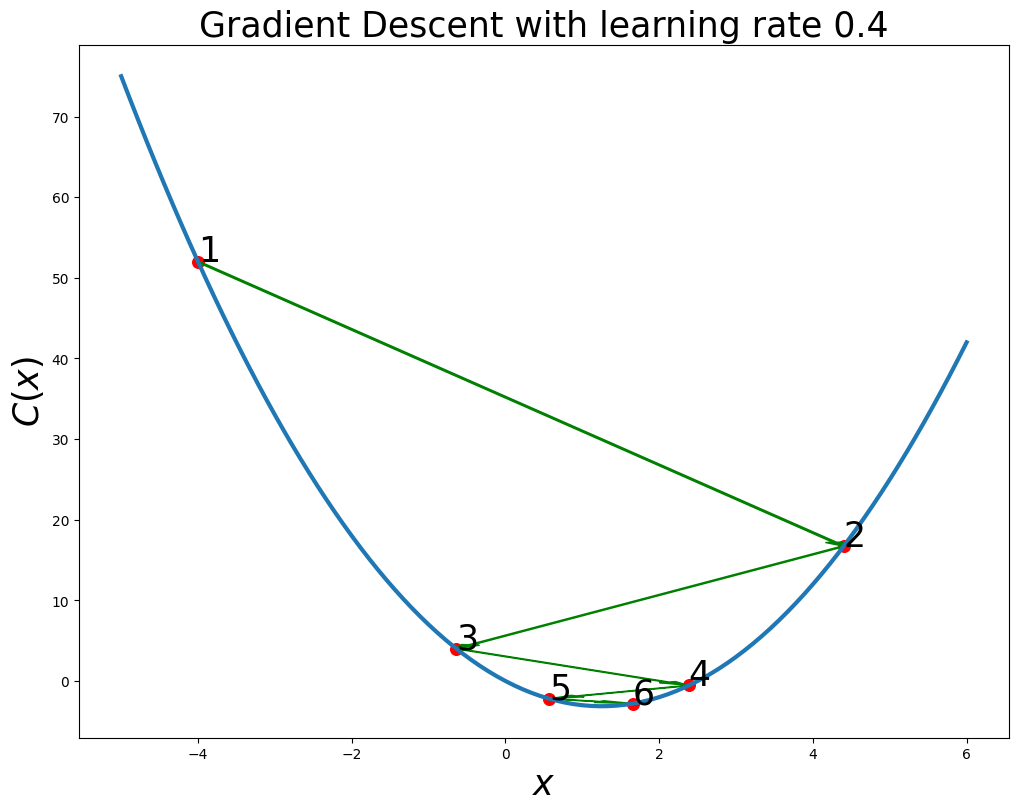

In [8]:
x0= -4
lr = 0.4
xs = compute_gradient_descent(x0=x0, lr=lr, steps=5)
plot_gradient_descent(xs, lr)

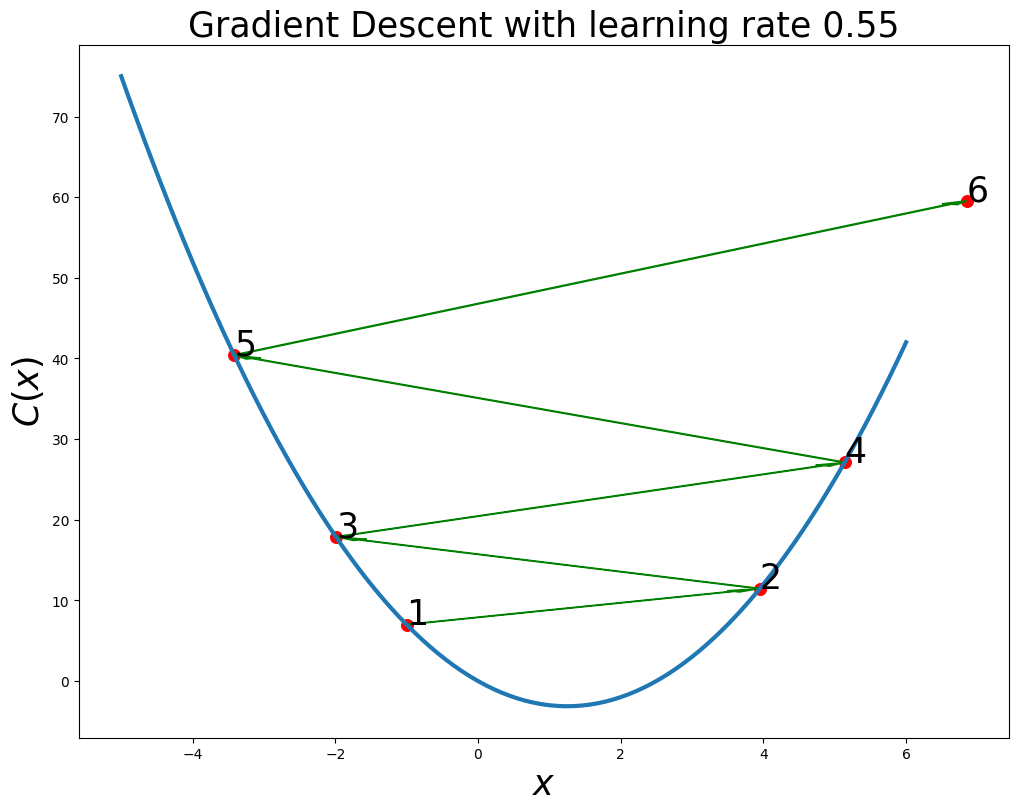

In [9]:
x0= -1
lr = 0.55

xs = compute_gradient_descent(x0=x0, lr=lr, steps=5)
plot_gradient_descent(xs, lr)